In [10]:
import os
from dotenv import load_dotenv
from QuantDataAPI import QuantDataAPI_Client
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

In [14]:
# Load the .env file into the system environment
load_dotenv()

APIKEY = os.getenv("QUANTDATA_API_KEY")
SESSION_DATE = '2026-07-13' # Not necessary to set, but lets keep it for consistency

client = QuantDataAPI_Client(APIKEY, output_type="pandas")

In [8]:
maxPain_series = client.get_max_pain_over_time(
    "NVDA",
    sessionDate = SESSION_DATE,
)

In [9]:
maxPain_series

,expirationDate,maxPainStrikePrice
0,2026-07-13,202.5
1,2026-07-15,200.0
2,2026-07-17,200.0
3,2026-07-20,200.0
4,2026-07-22,210.0
5,2026-07-24,200.0
6,2026-07-31,200.0
7,2026-08-07,195.0
8,2026-08-14,200.0
9,2026-08-21,200.0


In [11]:
# 1. Convert the 'expirationDate' column to proper datetime objects
maxPain_series['expirationDate'] = pd.to_datetime(maxPain_series['expirationDate'])

# 2. Get the current year dynamically
current_year = datetime.now().year

# 3. Filter the dataframe to only include rows where the expiration year matches the current year
current_year_data = maxPain_series[maxPain_series['expirationDate'].dt.year == current_year]

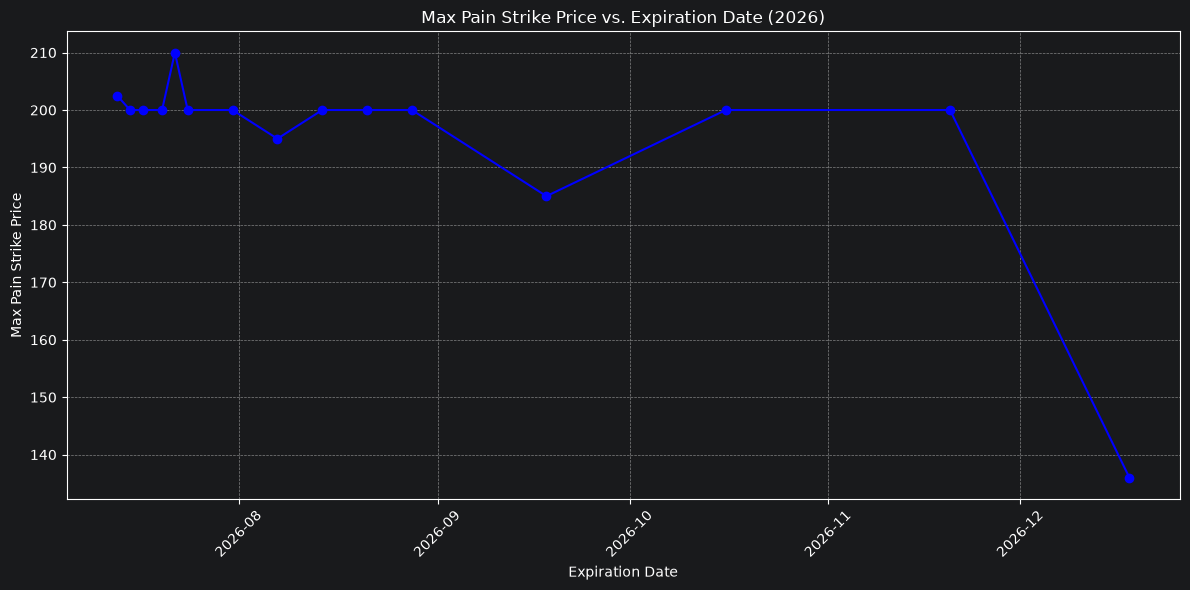

In [12]:
# Set up the figure size
plt.figure(figsize=(12, 6))

# Plot the filtered data instead of the full series
plt.plot(
    current_year_data['expirationDate'],
    current_year_data['maxPainStrikePrice'],
    marker='o',
    linestyle='-',
    color='b'
)

# Add titles and axis labels (updated to show the year)
plt.title(f'Max Pain Strike Price vs. Expiration Date ({current_year})')
plt.xlabel('Expiration Date')
plt.ylabel('Max Pain Strike Price')

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Rotate the X-axis dates so they don't overlap
plt.xticks(rotation=45)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Render the graph
plt.show()

In [20]:
# Unusual Orders
clientJSON = QuantDataAPI_Client(APIKEY, output_type="json") # Unusual Orders requires json output

unusual_Orders = clientJSON.get_order_flow_consolidated(
    sessionDate = SESSION_DATE,
    ticker = "NVDA",
    isUnusual = True,
    size = 1 # large output.  Only getting 1 for example.
)


In [21]:
unusual_Orders

{'data': [{'askPrice': 1.66,
   'bidAskSpread': 0.04,
   'bidPrice': 1.62,
   'contractType': 'CALL',
   'exchange': 'MIAX',
   'expirationDate': '2026-07-31',
   'dte': 18.042152777777776,
   'greeks': {'charm': -0.007704855749415676,
    'color': 0.00018836251221712437,
    'delta': 0.17605658089521997,
    'gamma': 0.014481734822501039,
    'omega': 22.036837649374526,
    'rho': 0.01693101980893956,
    'sigma': 0.3943443298339844,
    'speed': 0.0006830929965967815,
    'theta': -0.13282398046793134,
    'ultima': -1.4718835000688657,
    'vanna': 0.006680343191583079,
    'vega': 0.11724654187793336,
    'veta': 0.0064977327750446725,
    'vomma': 28.165422321354697,
    'zomma': -0.0019349890406203767},
   'id': '3ab1a7df-1582-4784-a609-d028e13c271d',
   'impliedVolatility': 39.43443298339844,
   'industry': 'SEMICONDUCTORS',
   'isETF': False,
   'isGoldenSweep': False,
   'isIndex': False,
   'isOpeningPosition': True,
   'isUnusual': True,
   'isVolumeGreaterThanOpenInterest'